# **US Super Store Sales Analysis**

## **Introduction**

**The data spans a robust four-year period from 2011 to 2015 . This dataset contains sales, profit, shipping and geographical information, categories and sub-categories of sold products across 147 countries.**

Brief description of columns:

- **Order Information**

    - **Order ID** – Unique identifier for each order.

    - **Order Date** – Date when the order was placed.

    - **Ship Date** – Date when the order was shipped.

    - **Ship Mode** – Shipping method (e.g., Standard Class, Second Class, First Class, Same Day).

- **Customer Information**

    - **Customer ID** – Unique identifier for each customer.

    - **Customer Name** – Name of the customer.

    - **Segment** – Customer segment (Consumer, Corporate, Home Office).

    - **Country** – Country where the customer is located.

    - **City / State / Region** – Geographic details of the customer.

- **Product Information**

    - **Product ID** – Unique identifier for each product.

    - **Category** – Broad product category (Furniture, Office Supplies, Technology).

    - **Sub-Category** – More specific product type (e.g., Chairs, Phones, Binders).

    - **Product Name** – Name/description of the product.

- **Sales & Profit Metrics**

    - **Sales** – Revenue generated from the order.

    - **Quantity** – Number of units sold.

    - **Discount** – Discount applied to the order.

    - **Profit** – Profit earned from the order after costs.

- **Geographic & Managerial**

    - **Region** – Region of the world (e.g., Asia, Europe, US).

    - **Postal Code** – Postal/ZIP code of the customer.

    - **Market** – Market grouping (e.g., APAC, EMEA).

- **Returns (separate sheet)**

    - **Returned** – Indicates whether an order was returned.

## **Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
import sklearn
from scipy import stats
import kaggle
from pathlib import Path
import sidetable

## **Display Settings**

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_info_rows', 1000)
import warnings
warnings.filterwarnings('ignore')

## **Data Ingestion & Exploration**

In [3]:
path = Path.cwd()
paths = path.parent.joinpath('data', 'raw')

file = []
for p in paths.glob('*'):
    file.append(p.name)

print(file)

['.gitkeep', 'Global Superstore.xls']


In [4]:
#find all excel files name in .xls sheet
df = pd.read_excel(paths/'Global Superstore.xls',sheet_name=None)
df.keys()

dict_keys(['Orders', 'Returns', 'People'])

In [5]:
orders = pd.read_excel(paths/'Global Superstore.xls',sheet_name='Orders')
return_df = pd.read_excel(paths/'Global Superstore.xls',sheet_name='Returns')
people_df = pd.read_excel(paths/'Global Superstore.xls',sheet_name='People')
display(orders.tail(1),
    return_df.tail(1),
    people_df.tail(1))

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,Country,Postal Code,Market,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
51289,6147,MX-2012-134460,2012-05-22,2012-05-26,Second Class,MC-18100,Mick Crebagga,Consumer,Tipitapa,Managua,Nicaragua,NaN,LATAM,Central,OFF-PA-10004155,Office Supplies,Paper,"Eaton Computer Printout Paper, 8.5 x 11",61.38,3,0.0,1.8,0.002,High


,Returned,Order ID,Market
1172,Yes,CA-2014-168193,United States


,Person,Region
12,Alejandro Ballentine,Southeast Asia


In [6]:
order_df = orders.copy()
display('Orders shape :',order_df.shape, 
        'Returns shape', return_df.shape, 
        'People shape',people_df.shape)

'Orders shape :'

(51290, 24)

'Returns shape'

(1173, 3)

'People shape'

(13, 2)

In [7]:
# remove whitespaces from column names and lower case of all columns
dfs = [order_df, return_df, people_df]
for df in dfs:
    df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")


In [8]:
order_df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   row_id          51290 non-null  int64         
 1   order_id        51290 non-null  object        
 2   order_date      51290 non-null  datetime64[ns]
 3   ship_date       51290 non-null  datetime64[ns]
 4   ship_mode       51290 non-null  object        
 5   customer_id     51290 non-null  object        
 6   customer_name   51290 non-null  object        
 7   segment         51290 non-null  object        
 8   city            51290 non-null  object        
 9   state           51290 non-null  object        
 10  country         51290 non-null  object        
 11  postal_code     9994 non-null   float64       
 12  market          51290 non-null  object        
 13  region          51290 non-null  object        
 14  product_id      51290 non-null  object        
 15  ca

In [9]:
return_df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1173 entries, 0 to 1172
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   returned  1173 non-null   object
 1   order_id  1173 non-null   object
 2   market    1173 non-null   object
dtypes: object(3)
memory usage: 27.6+ KB


In [10]:
dtype_df = pd.DataFrame({
    'dtype': order_df.dtypes,
    'nunique': order_df.nunique(),
    'unique' : [order_df[col].unique() for col in order_df.columns]
}, index=order_df.columns)
display(dtype_df)

,dtype,nunique,unique
row_id,int64,51290,"[32298, 26341, 25330, 13524, 47221, 22732, 305..."
order_id,object,25035,"[CA-2012-124891, IN-2013-77878, IN-2013-71249,..."
order_date,datetime64[ns],1430,"[2012-07-31 00:00:00, 2013-02-05 00:00:00, 201..."
ship_date,datetime64[ns],1464,"[2012-07-31 00:00:00, 2013-02-07 00:00:00, 201..."
ship_mode,object,4,"[Same Day, Second Class, First Class, Standard..."
customer_id,object,1590,"[RH-19495, JR-16210, CR-12730, KM-16375, RH-94..."
customer_name,object,795,"[Rick Hansen, Justin Ritter, Craig Reiter, Kat..."
segment,object,3,"[Consumer, Corporate, Home Office]"
city,object,3636,"[New York City, Wollongong, Brisbane, Berlin, ..."
state,object,1094,"[New York, New South Wales, Queensland, Berlin..."


**Check whether the object columns contains invalid UTF-8 entries?**

In [11]:
def find_invalid_utf8(df):
    """
    Identify string columns in a DataFrame that contain invalid UTF-8 entries.
    
    Parameters:
        df (pd.DataFrame): Input DataFrame
    
    Returns:
        dict: {column_name: invalid_count} for columns with >0 invalid entries
    """
    # Select only object (string) columns
    string_cols = df.select_dtypes(include=['object'])
    
    # Helper function to check UTF-8 validity
    def is_valid_utf8(value):
        try:
            if isinstance(value, str):
                value.encode('utf-8')
            return True
        except UnicodeEncodeError:
            return False
    
    # Count invalid entries per column
    invalid_counts = {}
    for col in string_cols.columns:
        count = (~string_cols[col].apply(is_valid_utf8)).sum()
        if count > 0:
            invalid_counts[col] = count
    
    return invalid_counts

# Apply for orders and returns data
orders_invalid_cols = find_invalid_utf8(order_df)
returns_invalid_cols = find_invalid_utf8(return_df)
person_invalid_cols = find_invalid_utf8(people_df)
print(orders_invalid_cols); print(returns_invalid_cols); print(person_invalid_cols)

{}
{}
{}


## **Missing Value Analysis**

In [12]:
missing_df = order_df.stb.missing()
missing_df[missing_df['percent']>0]

,missing,total,percent
postal_code,41296,51290,80.51472


In [13]:
return_df.stb.missing()

,missing,total,percent
returned,0,1173,0.0
order_id,0,1173,0.0
market,0,1173,0.0


- **order_df has only ~81% missing values in postal code column. We can impute it with mode or drop it as well since it is not a key column for analysis.**

- **return_df has no missing values.**

- **raw_id column has all distinct values which of no use drop it.**

In [14]:
order_df.duplicated().sum()

0

## **Duplicate Data**

In [15]:
data = {'order' : order_df, 'returns' : return_df, 'people' : people_df}
for name, dfs in data.items():
    dup_count = dfs.duplicated().sum()
    print(f"Duplicate Data in {name} data = {dup_count}")

Duplicate Data in order data = 0
Duplicate Data in returns data = 0
Duplicate Data in people data = 0


### **Merged Orders and Returns Data for Analysis**

In [16]:
from sympy import intersection


(order_df.columns).intersection(return_df.columns)

Index(['order_id', 'market'], dtype='object')

In [17]:
print(f"Market in order data: {set(order_df['market'])}")
print(f"Market in return data: {set(return_df['market'])}")
print(f"Market in order data not in return: {(set(order_df['market'])).difference(set(return_df['market']))}")
print(f"Market in return data not in order: {(set(return_df['market'])).difference(set(order_df['market']))}")
print((set(order_df['market'])).difference(set(return_df['market'])))

Market in order data: {'EU', 'LATAM', 'Canada', 'US', 'EMEA', 'APAC', 'Africa'}
Market in return data: {'EU', 'LATAM', 'APAC', 'United States'}
Market in order data not in return: {'Africa', 'Canada', 'US', 'EMEA'}
Market in return data not in order: {'United States'}
{'Africa', 'Canada', 'US', 'EMEA'}


In [18]:
def clean_return_df(raw_df):
    clean_df = raw_df.copy()
    # transform return column to bool type
    clean_df['returned'] = clean_df['returned'].map({'Yes': True, 'No': False})
    # since order has 'US' market only but returns has 'Unites States' market name, we will change 'United States' to 'US'
    clean_df['market'].replace({'United States': 'US'}, inplace=True)
    return clean_df

# clean returns data
returned_df = clean_return_df(return_df)

In [19]:
# Complete order-returns data for furthur analysis
merged_df = pd.merge(order_df, returned_df, on =['order_id', 'market'], how='left')
# merged_df basic information
print(f"Merged data shape: {merged_df.shape}", '\n')
# Duplicate entries and missing values
print(f"Merged data duplicate data: {merged_df.duplicated().sum()}",'\n')
miss_df = merged_df.stb.missing()
miss_df = miss_df.query("percent > 0")
print(f"Missing data in merged data:\n {miss_df}")

Merged data shape: (51290, 25) 

Merged data duplicate data: 0 

Missing data in merged data:
              missing  total   percent
returned       48247  51290  94.06707
postal_code    41296  51290  80.51472


In [20]:
# Replace returned missing values with False bcoz they are non-returned orders and postal_code will be dropped if it's redundant.
# About returned column
print(f"Data of 'returned' column type : {merged_df['returned'].dtype}",'\n')
print(f"Data counts of 'returned' column :\n{merged_df['returned'].value_counts(dropna=False)}")


Data of 'returned' column type : object 

Data counts of 'returned' column :
returned
NaN     48247
True     3043
Name: count, dtype: int64


In [21]:
merged_df['returned'] = merged_df['returned'].fillna(False)
merged_df['returned'].value_counts()

returned
False    48247
True      3043
Name: count, dtype: int64

### **Descriptive Statistics**

**Categorical Variables**

In [22]:
merged_df.describe(exclude='number')

,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,city,state,country,market,region,product_id,category,sub-category,product_name,order_priority,returned
count,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290
unique,25035,NaN,NaN,4,1590,795,3,3636,1094,147,7,13,10292,3,17,3788,4,2
top,CA-2014-100111,NaN,NaN,Standard Class,PO-18850,Muhammed Yedwab,Consumer,New York City,California,United States,APAC,Central,OFF-AR-10003651,Office Supplies,Binders,Staples,Medium,False
freq,14,NaN,NaN,30775,97,108,26518,915,2001,9994,11002,11117,35,31273,6152,227,29433,48247
mean,NaN,2013-05-11 21:26:49.155781120,2013-05-15 20:42:42.745174528,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,2011-01-01 00:00:00,2011-01-03 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,2012-06-19 00:00:00,2012-06-23 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,2013-07-08 00:00:00,2013-07-12 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,2014-05-22 00:00:00,2014-05-26 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,2014-12-31 00:00:00,2015-01-07 00:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Continuous Variables**

In [23]:
# highlight values
def highlighted_values(val):
    if pd.isna(val):
        return "background-color:gray"
    elif val==0:
        return "background-color:yellow; color:black"
    elif val < 0:
        return "background-color:red; color:white"
    else:
        return ""

In [24]:
cont_df = merged_df.describe(include='number')
display(cont_df.style.applymap(highlighted_values))

,row_id,postal_code,sales,quantity,discount,profit,shipping_cost
count,51290.000000,9994.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,25645.500000,55190.379428,246.490581,3.476545,0.142908,28.610982,26.375818
std,14806.291990,32063.693350,487.565361,2.278766,0.212280,174.340972,57.296810
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000,0.002000
25%,12823.250000,23223.000000,30.758625,2.000000,0.000000,0.000000,2.610000
50%,25645.500000,56430.500000,85.053000,3.000000,0.000000,9.240000,7.790000
75%,38467.750000,90008.000000,251.053200,5.000000,0.200000,36.810000,24.450000
max,51290.000000,99301.000000,22638.480000,14.000000,0.850000,8399.976000,933.570000


**Observations:**

- **Discount :**  The discount column has a lot of zero values, which might indicate that many orders were made without any discount. Or, there is any other reason we need to investigate furthur.

- **Profit :**  The profit column has a negative value which indicates that there are some orders that resulted in a loss and profit value is zero as well which inidicates that there are some orders that did not generate any profit, or these values are some error need to investigate furthur.


In [25]:
# Doing US Super Store Sales Analysis 
us_merged_df = merged_df.query("country == 'United States'")

In [26]:
np.sort(us_merged_df['country'].unique())

array(['United States'], dtype=object)

## **Univariate Visualization**

### **Categorical Variables**

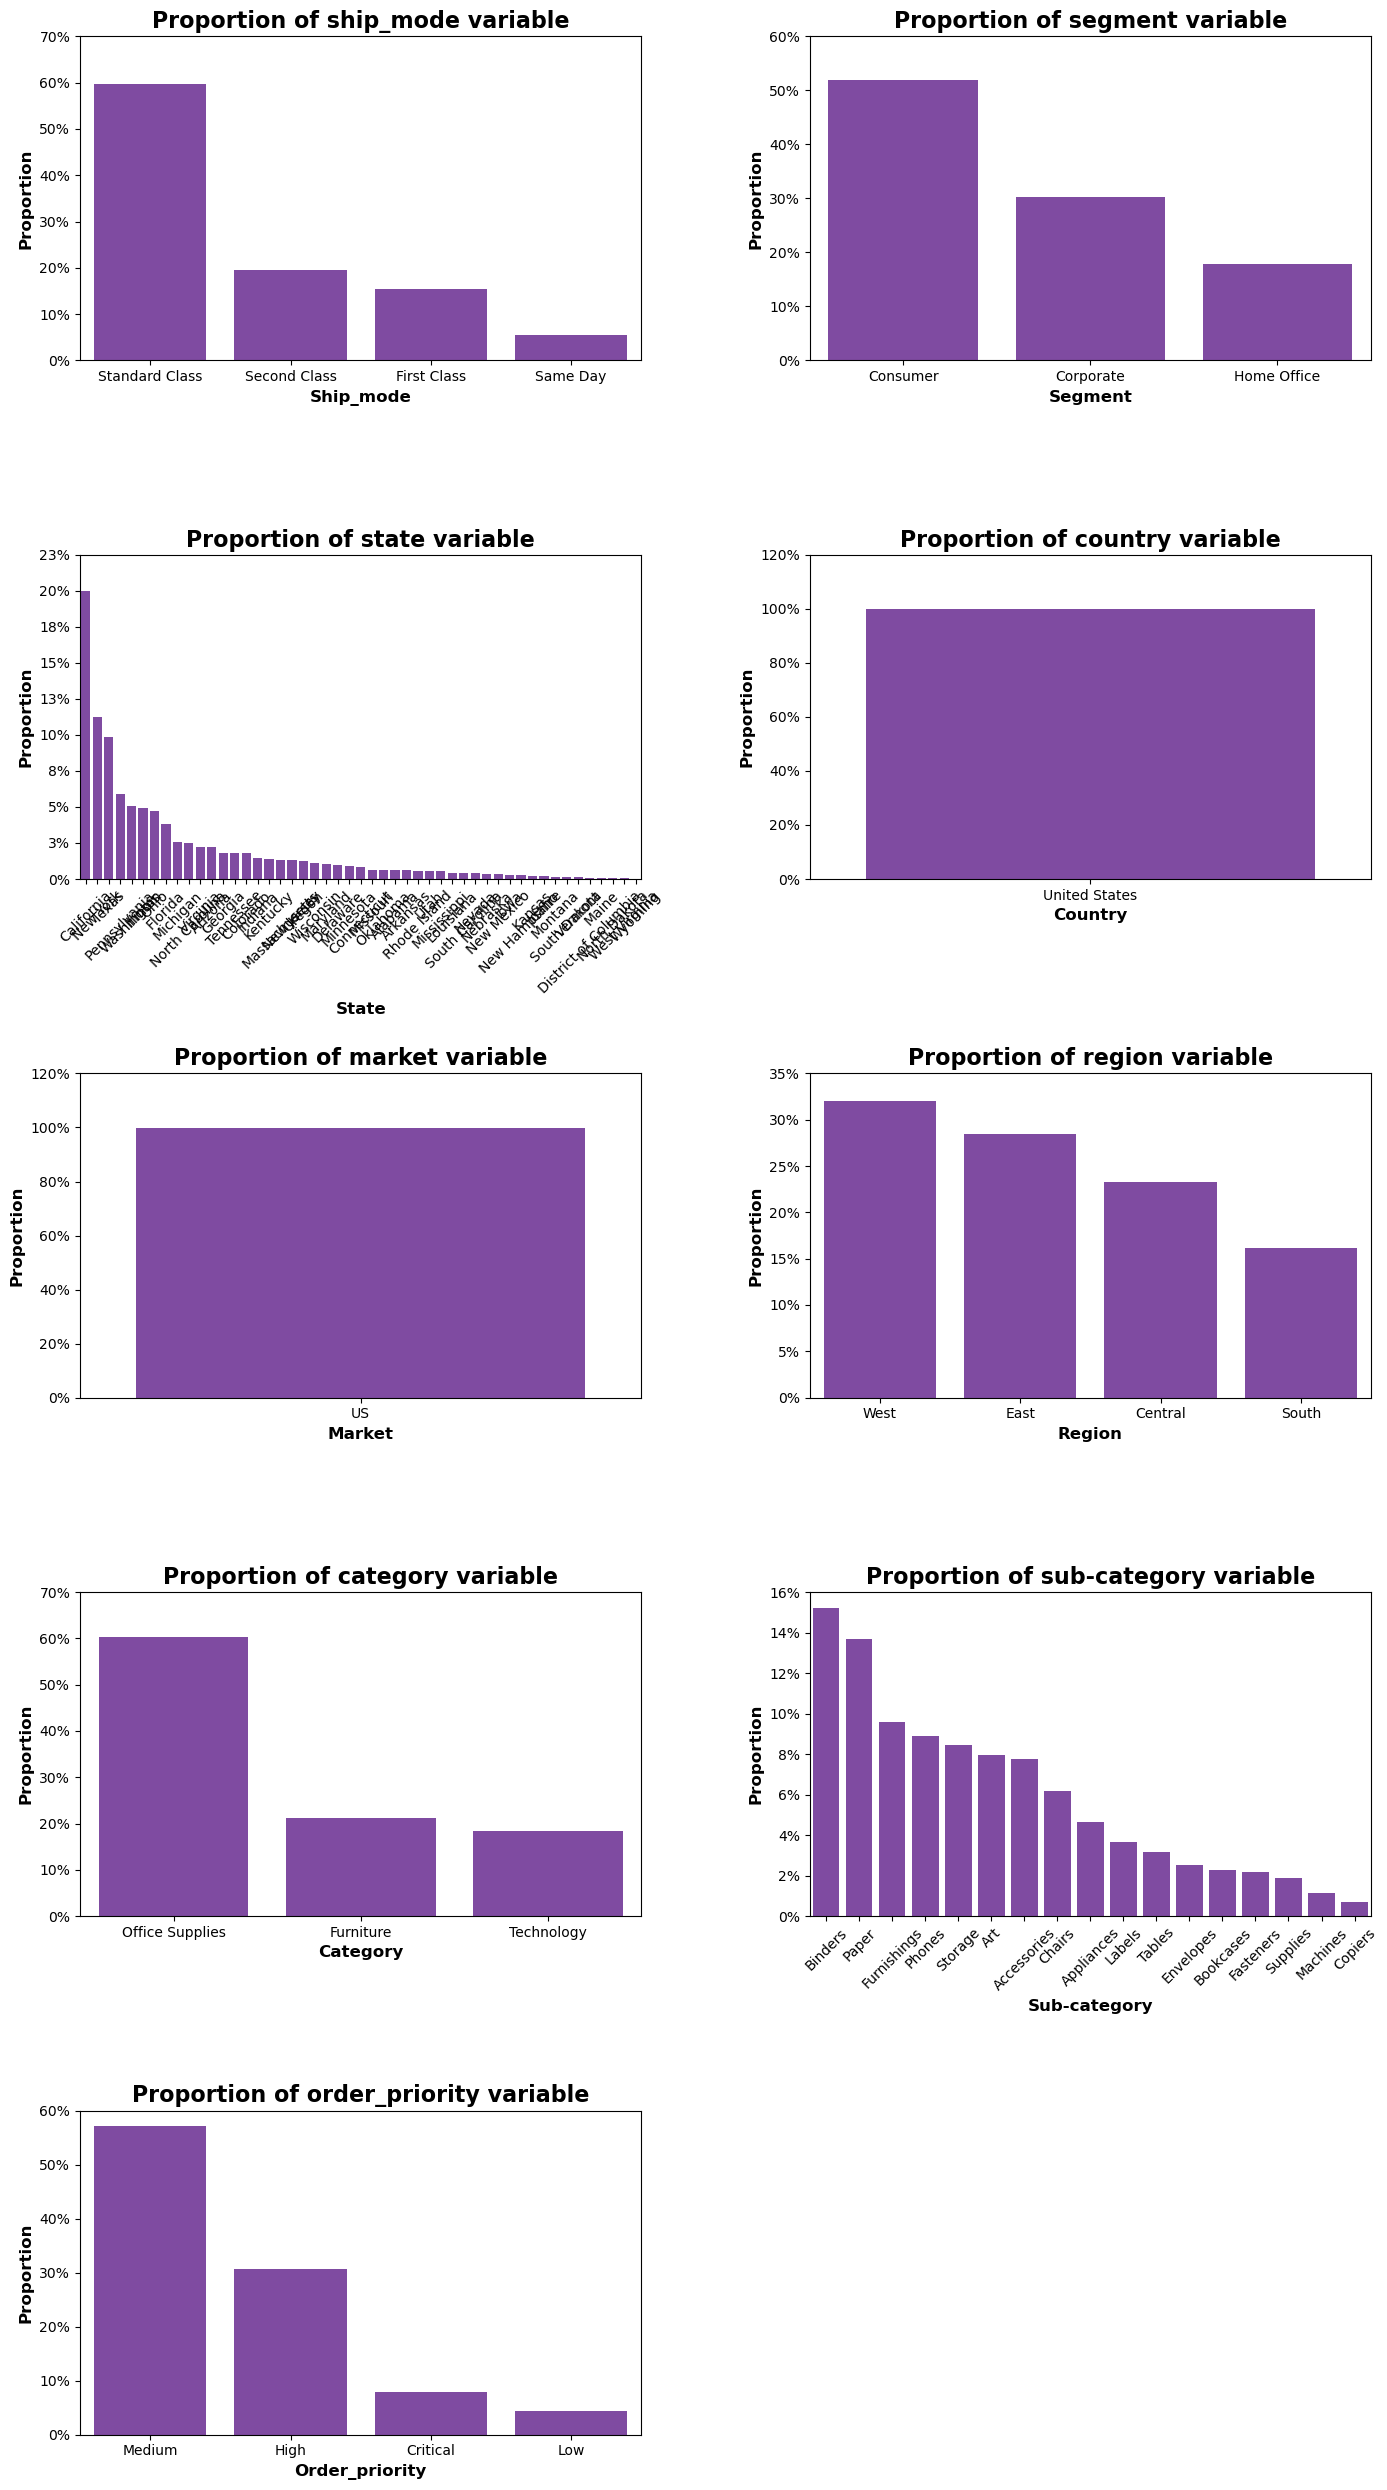

In [54]:
import math
# Select categorical columns except specified ones
all_column = us_merged_df.select_dtypes(include=['category', 'object']).drop(
    columns=['city','order_id', 'customer_id', 'customer_name', 'product_id', 'product_name'],
    errors='ignore'
)

# Dynamically calculate grid size
n_cols = 2   # fix 2 columns
n_rows = math.ceil(len(all_column.columns) / n_cols)

fig, ax = plt.subplots(n_rows, n_cols, figsize=(14, 5*n_rows))
ax = ax.flatten()

for i, col in enumerate(all_column.columns):
    sns.countplot(
        data=all_column,
        x=col,
        order=all_column[col].value_counts().index,
        color='#823DAF',
        ax=ax[i]
    )

    # Format y-axis as proportions
    total = len(all_column[col])
    ax[i].set_yticks(ax[i].get_yticks())
    ax[i].set_yticklabels([f"{val/total:.0%}" for val in ax[i].get_yticks()])

    # Labels and titles
    ax[i].set_xlabel(col.capitalize(), fontsize=12, fontweight='bold')
    ax[i].set_ylabel("Proportion", fontsize=12, fontweight='bold')
    ax[i].set_title(f"Proportion of {col} variable", fontsize=16, fontweight='bold')

    # Rotate x labels if too many categories
    if all_column[col].nunique() > 4:
        ax[i].tick_params(axis='x', rotation=45)
    else:
        ax[i].tick_params(axis='x', rotation=0)

# 🔑 Hide unused subplots
for j in range(len(all_column.columns), len(ax)):
    fig.delaxes(ax[j])

# Layout adjustments
plt.tight_layout()
plt.subplots_adjust(wspace=0.3, hspace=0.6)
plt.show()
